# Song Duration Analysis

Compare the duration distributions of songs across the three collections:
**LastFM** (human-curated), **Suno** (AI-generated), and **Udio** (AI-generated).

Durations are extracted from `_musical_form.lab` files (the start time of the `end` marker).

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

COLLECTIONS = ['lastfm', 'suno', 'udio']
DATASET_ROOT = '/workspace/dataset'
COLORS = {'lastfm': '#51BFFF', 'suno': '#FFC400', 'udio': '#FF5B0E'}

def get_duration(lab_path):
    """Extract song duration (seconds) from a _musical_form.lab file.
    The duration is the start timestamp of the 'end' segment."""
    last_start = 0.0
    with open(lab_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3:
                last_start = float(parts[0])
                if parts[2] == 'end':
                    return float(parts[0])
    # Fallback: return the last end timestamp
    return float(parts[1]) if parts else last_start

# Collect durations per collection
durations = {}
for collection in COLLECTIONS:
    coll_path = os.path.join(DATASET_ROOT, collection)
    durs = []
    for song_id in sorted(os.listdir(coll_path)):
        song_dir = os.path.join(coll_path, song_id)
        if not os.path.isdir(song_dir):
            continue
        lab = os.path.join(song_dir, f'{song_id}_musical_form.lab')
        if not os.path.exists(lab):
            continue
        d = get_duration(lab)
        if d > 0:
            durs.append(d)
    durations[collection] = np.array(durs)
    print(f'{collection:8s}: {len(durs):>6,} songs  |  '
          f'mean {np.mean(durs):6.1f}s  median {np.median(durs):6.1f}s  '
          f'std {np.std(durs):5.1f}s  '
          f'range [{np.min(durs):.1f}s – {np.max(durs):.1f}s]')

lastfm  : 19,902 songs  |  mean  255.4s  median  233.4s  std 152.5s  range [13.8s – 4457.2s]
suno    : 19,965 songs  |  mean  172.9s  median  172.4s  std  54.7s  range [3.2s – 1061.9s]
udio    : 19,987 songs  |  mean  141.4s  median  127.7s  std  98.1s  range [3.7s – 931.6s]


## Duration Distribution — Overlaid Histograms

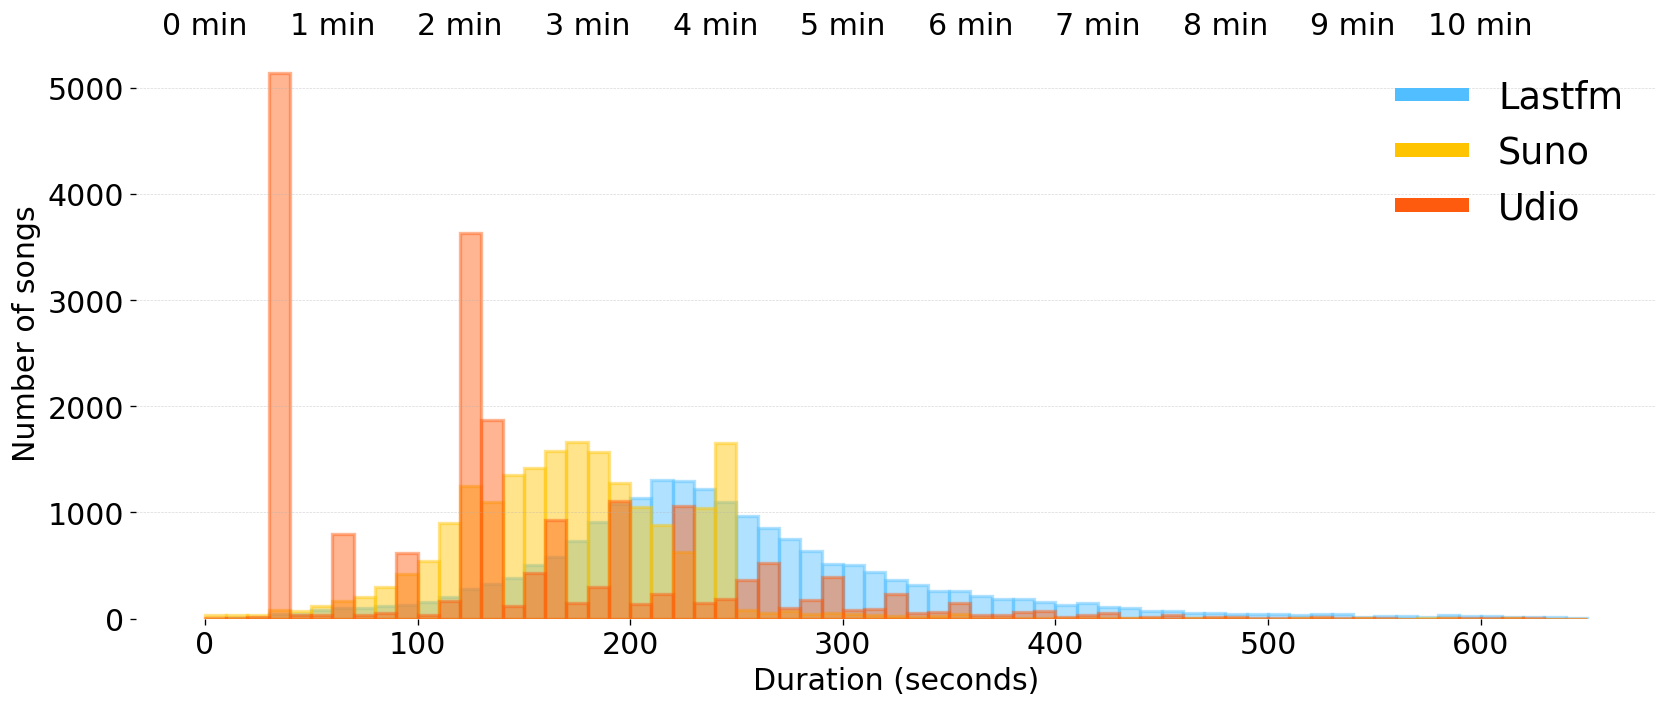

In [18]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 6), dpi=120)

bins = np.arange(0, 660, 10)  # 10-second bins up to 11 minutes

for col in COLLECTIONS:
    ax.hist(durations[col], bins=bins, alpha=0.45, color=COLORS[col],
            edgecolor=COLORS[col], linewidth=2.0)

# Legend with full-opacity colors
legend_handles = [mpatches.Patch(facecolor=COLORS[col], edgecolor='none',
                                  label=col.capitalize())
                  for col in COLLECTIONS]
ax.legend(handles=legend_handles, fontsize=22, frameon=False,
          handlelength=2.0, handleheight=0.2)

ax.set_xlabel('Duration (seconds)', fontsize=18)
ax.set_ylabel('Number of songs', fontsize=18)
ax.tick_params(axis='both', labelsize=18)
ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.5)
for spine in ax.spines.values():
    spine.set_visible(False)

# Add minute markers on top axis
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
minute_ticks = np.arange(0, 660, 60)
ax2.set_xticks(minute_ticks)
ax2.set_xticklabels([f'{int(t//60)} min' for t in minute_ticks], fontsize=18)
ax2.tick_params(length=0)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('../Figures/duration_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

## Duration Distribution — KDE (Kernel Density Estimate)

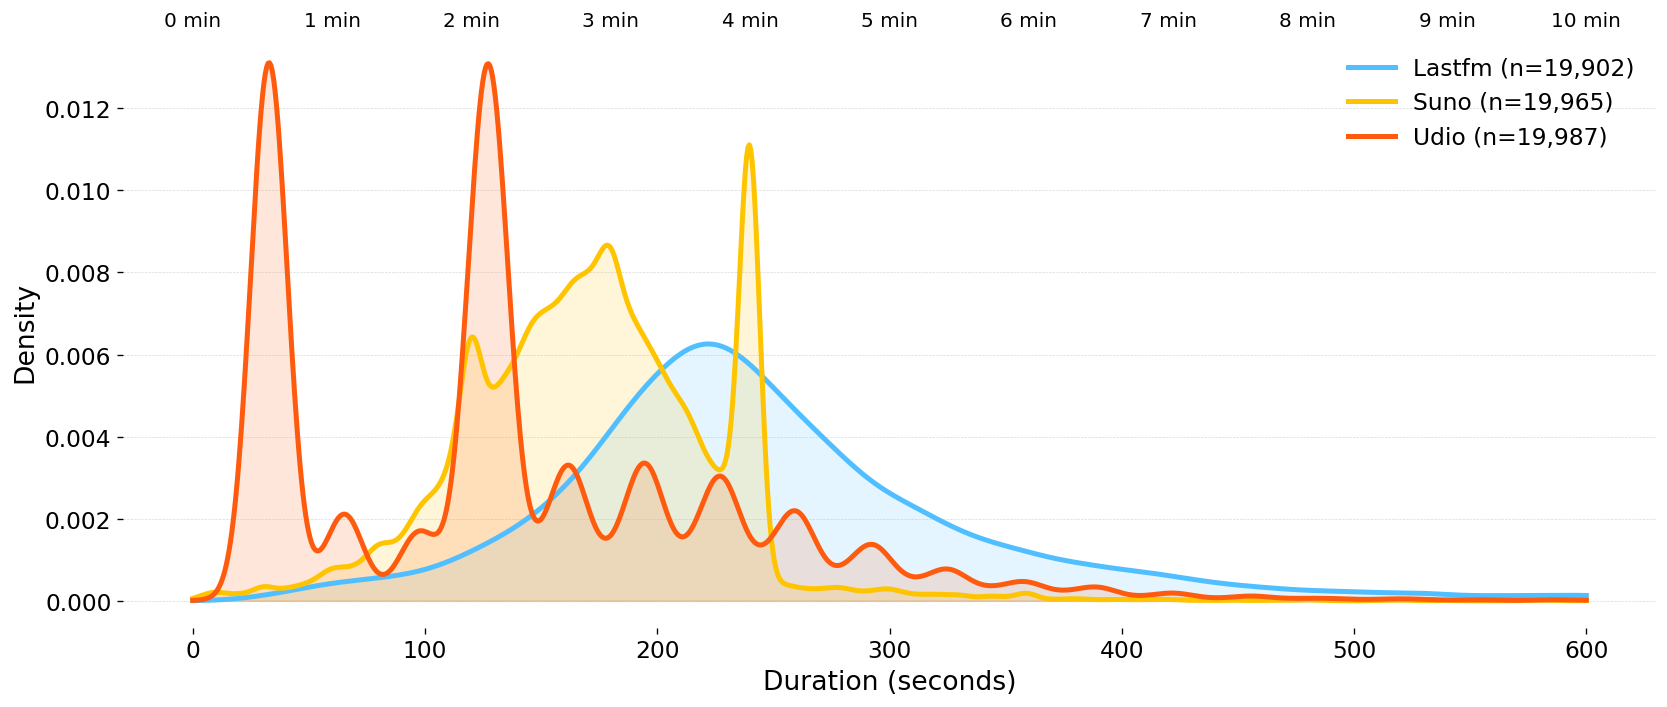

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6), dpi=120)

for col in COLLECTIONS:
    d = durations[col]
    kde = stats.gaussian_kde(d, bw_method=0.08)
    x = np.linspace(0, 600, 1000)
    ax.plot(x, kde(x), color=COLORS[col], linewidth=3,
            label=col.capitalize())
    ax.fill_between(x, kde(x), alpha=0.15, color=COLORS[col])

ax.set_xlabel('Duration (seconds)', fontsize=16)
ax.set_ylabel('Density', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=14, frameon=False)
ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.5)
for spine in ax.spines.values():
    spine.set_visible(False)

# Minute markers
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
minute_ticks = np.arange(0, 660, 60)
ax2.set_xticks(minute_ticks)
ax2.set_xticklabels([f'{int(t//60)} min' for t in minute_ticks], fontsize=12)
ax2.tick_params(length=0)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('../Figures/duration_kde.png', dpi=300, bbox_inches='tight')
plt.show()

## Box Plot Comparison

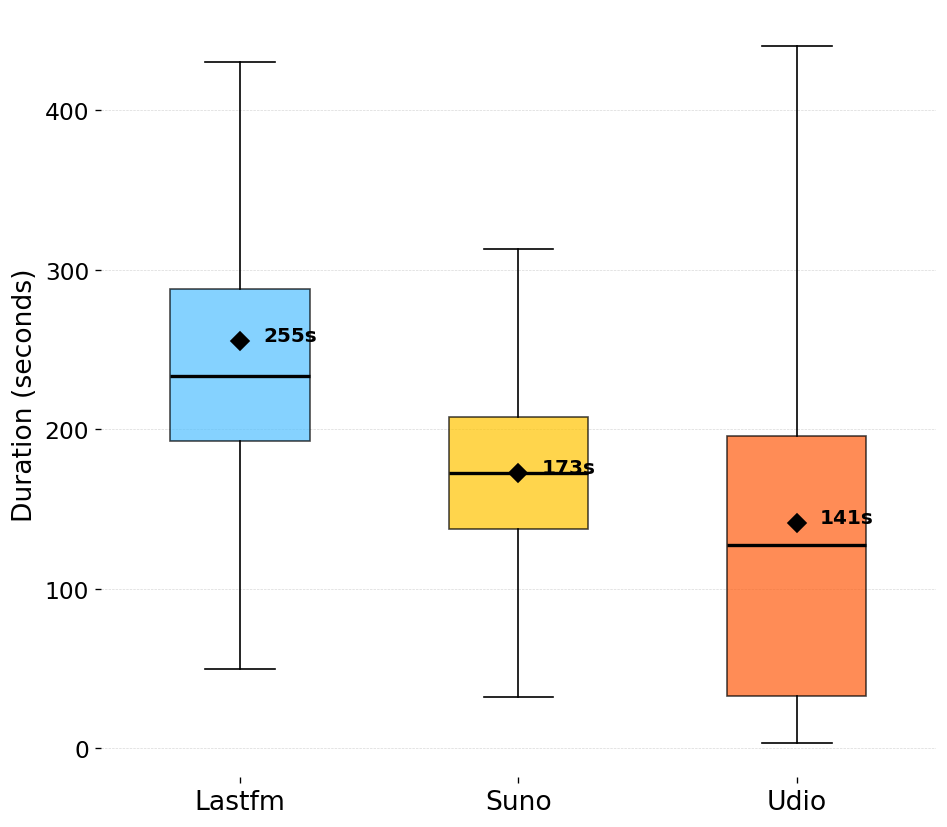

In [6]:
fig, ax = plt.subplots(figsize=(8, 7), dpi=120)

box_data = [durations[col] for col in COLLECTIONS]
bp = ax.boxplot(box_data, vert=True, patch_artist=True, widths=0.5,
                showfliers=False,  # hide outliers for cleaner view
                medianprops=dict(color='black', linewidth=2))

for patch, col in zip(bp['boxes'], COLLECTIONS):
    patch.set_facecolor(COLORS[col])
    patch.set_alpha(0.7)

ax.set_xticklabels([c.capitalize() for c in COLLECTIONS], fontsize=16)
ax.set_ylabel('Duration (seconds)', fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.5)
for spine in ax.spines.values():
    spine.set_visible(False)

# Add mean markers
for i, col in enumerate(COLLECTIONS):
    mean_val = np.mean(durations[col])
    ax.plot(i + 1, mean_val, 'D', color='black', markersize=8, zorder=5)
    ax.annotate(f'{mean_val:.0f}s', (i + 1, mean_val), textcoords='offset points',
                xytext=(14, 0), ha='left', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../Figures/duration_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary Statistics

In [5]:
# Build summary table
rows = []
for col in COLLECTIONS:
    d = durations[col]
    rows.append({
        'Collection': col.capitalize(),
        'N': len(d),
        'Mean (s)': f'{np.mean(d):.1f}',
        'Median (s)': f'{np.median(d):.1f}',
        'Std (s)': f'{np.std(d):.1f}',
        'Min (s)': f'{np.min(d):.1f}',
        'Max (s)': f'{np.max(d):.1f}',
        'Q25 (s)': f'{np.percentile(d, 25):.1f}',
        'Q75 (s)': f'{np.percentile(d, 75):.1f}',
        '< 2 min (%)': f'{100 * np.sum(d < 120) / len(d):.1f}',
        '2–4 min (%)': f'{100 * np.sum((d >= 120) & (d < 240)) / len(d):.1f}',
        '> 4 min (%)': f'{100 * np.sum(d >= 240) / len(d):.1f}',
    })

df_summary = pd.DataFrame(rows).set_index('Collection')
display(df_summary)

# Statistical tests (KS test between each pair)
print('\nKolmogorov-Smirnov tests:')
pairs = [('lastfm', 'suno'), ('lastfm', 'udio'), ('suno', 'udio')]
for a, b in pairs:
    stat, p = stats.ks_2samp(durations[a], durations[b])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'  {a.capitalize():8s} vs {b.capitalize():8s}:  D={stat:.4f}  p={p:.2e}  {sig}')

,N,Mean (s),Median (s),Std (s),Min (s),Max (s),Q25 (s),Q75 (s),< 2 min (%),2–4 min (%),> 4 min (%)
Collection,,,,,,,,,,,
Lastfm,19902,255.4,233.4,152.5,13.8,4457.2,192.5,287.7,4.9,49.0,46.0
Suno,19965,172.9,172.4,54.7,3.2,1061.9,137.7,207.9,14.6,74.2,11.2
Udio,19987,141.4,127.7,98.1,3.7,931.6,32.8,195.9,34.7,50.6,14.7



Kolmogorov-Smirnov tests:
  Lastfm   vs Suno    :  D=0.4244  p=0.00e+00  ***
  Lastfm   vs Udio    :  D=0.5595  p=0.00e+00  ***
  Suno     vs Udio    :  D=0.4055  p=0.00e+00  ***


## Listen to a Short Udio Song

In [20]:
from IPython.display import Audio, display, HTML

AUDIO_ROOT = '/mnt/Aimir_HD'

# Find udio songs shorter than 60 seconds, sorted by duration
udio_durs = durations['udio']
udio_ids = []
udio_path = os.path.join(DATASET_ROOT, 'udio')
for song_id in sorted(os.listdir(udio_path)):
    song_dir = os.path.join(udio_path, song_id)
    if not os.path.isdir(song_dir):
        continue
    lab = os.path.join(song_dir, f'{song_id}_musical_form.lab')
    if not os.path.exists(lab):
        continue
    d = get_duration(lab)
    if 0 < d < 60:
        udio_ids.append((song_id, d))

udio_ids.sort(key=lambda x: x[1])
print(f'Found {len(udio_ids)} udio songs shorter than 60 seconds.\n')
print('Shortest 10:')
for sid, dur in udio_ids[:10]:
    print(f'  {sid}  —  {dur:.1f}s')

# Pick one of the shortest and play it
pick_id, pick_dur = udio_ids[1]
audio_path = os.path.join(AUDIO_ROOT, 'udio', 'audio', f'{pick_id}.mp3')
print(f'\n▶ Playing: {pick_id}  ({pick_dur:.1f}s)')
display(Audio(audio_path))

Found 5233 udio songs shorter than 60 seconds.

Shortest 10:
  8627d20f-c72d-4473-85b5-c34f3df82b5e  —  3.7s
  7e895107-dcb2-4e4a-baec-edd2e0f13e66  —  9.6s
  00b2279c-db8b-46f3-80b4-fda52a2845f3  —  12.8s
  1f664258-4a5d-4a29-8174-652ec27e90c5  —  12.9s
  0b40aa20-a62b-41e2-9af1-1571912fc156  —  14.1s
  f3983c9c-5379-4a28-a31c-773c3a10c76a  —  15.7s
  e7e36724-7fb5-4d45-a843-8482a559f546  —  15.7s
  600e7a21-387b-4ae1-a8a6-fadb5e07d9d8  —  16.0s
  4e94b461-f388-4b43-9f70-0cbecac69cdc  —  18.6s
  a9e72cce-a912-4319-9eee-6bd560807530  —  19.6s

▶ Playing: 7e895107-dcb2-4e4a-baec-edd2e0f13e66  (9.6s)
